
# Демонстрация MoCo и сравнение с UMAP на синтетических данных

В этом ноутбуке мы:

1. Сгенерируем синтетические данные в виде нескольких кластеров:
   - в двумерном пространстве (для наглядности),
   - в более высокой размерности (для демонстрации задачи снижения размерности).
2. Реализуем **упрощённую версию MoCo** на PyTorch:
   - с online-энкодером,
   - с momentum-энкодером,
   - с InfoNCE loss,
3. Обучим MoCo на синтетических данных и посмотрим на эмбеддинги:
   - в случае 2D-данных (структура кластеров должна сохраниться),
   - в случае high-dim данных (фактически снижение размерности).
4. Сравним результат с классическим методом снижения размерности **UMAP** на тех же данных.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# UMAP понадобится на этапе сравнения.
# Если он не установлен, раскомментируйте строку ниже в своей среде:
# !pip install umap-learn

try:
    import umap
except ImportError:
    umap = None
    print("UMAP не найден. Установите пакет `umap-learn`, чтобы запустить сравнение.")



## Синтетические данные

Сгенерируем несколько кластеров с помощью `sklearn.datasets.make_blobs`.

- В 2D варианте мы сможем видеть исходные данные и эмбеддинги на одной плоскости.
- В high-dim варианте (например, 20 измерений) мы будем использовать MoCo как метод снижения размерности до 2D.


In [3]:
def generate_blobs_2d(n_samples=1000, n_clusters=4, cluster_std=0.7, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=n_clusters,
        n_features=2,
        cluster_std=cluster_std,
        random_state=random_state
    )
    return X.astype(np.float32), y

In [4]:
def generate_blobs_high_dim(n_samples=2000, n_clusters=4, n_features=20, cluster_std=1.0, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=n_clusters,
        n_features=n_features,
        cluster_std=cluster_std,
        random_state=random_state
    )
    return X.astype(np.float32), y

In [5]:
# Пример: посмотрим на 2D-данные
X2d, y2d = generate_blobs_2d(n_samples=1000,
                             n_clusters=4,
                             cluster_std=1.5,
                             random_state=42)

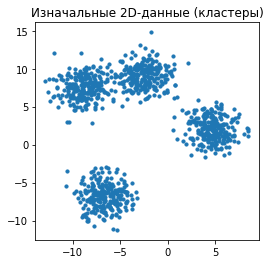

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(X2d[:, 0], X2d[:, 1], s=10)
plt.title("Изначальные 2D-данные (кластеры)")
plt.show()

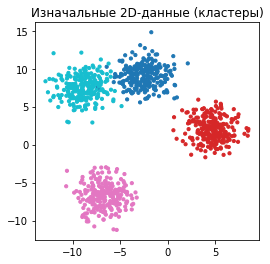

In [7]:
plt.figure(figsize=(4, 4))
plt.scatter(X2d[:, 0], X2d[:, 1], c=y2d, cmap="tab10", s=10)
plt.title("Изначальные 2D-данные (кластеры)")
plt.show()


## Dataset и простые аугментации

Для MoCo нам нужны *позитивные пары*.  
В классическом варианте на изображениях это разные аугментации одной и той же картинки.

Здесь, для синтетических данных, мы сделаем очень простую аугментацию:
- к исходной точке добавим небольшой гауссов шум.

Таким образом, две аугментации одной и той же точки будут образовывать **позитивную пару**.


In [8]:
class BlobDataset(Dataset):
    def __init__(self, X, y, noise_std=0.05):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()
        self.noise_std = noise_std

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        label = self.y[idx]

        # Две аугментации одной точки (позитивная пара)
        aug1 = x + self.noise_std * torch.randn_like(x)
        aug2 = x + self.noise_std * torch.randn_like(x)
        return aug1, aug2, label



## Модель MoCo (упрощённая)

Реализуем:

- **энкодер** как небольшой MLP,
- **online-энкодер** и **momentum-энкодер** с одинаковой архитектурой,
- **очередь негативов**,
- **InfoNCE loss**.

Это не промышленная реализация, а максимально компактная и наглядная версия для демонстрации.


In [9]:
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, proj_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        z = self.net(x)
        z = F.normalize(z, dim=-1)  # нормализация для косинусного сходства
        return z

In [11]:
class MoCo(nn.Module):
    def __init__(self, input_dim, proj_dim=2, hidden_dim=64, K=1024, m=0.999, T=0.07, device="cpu"):
        super().__init__()
        self.device = device

        # online encoder
        self.encoder_q = MLPEncoder(input_dim, proj_dim, hidden_dim).to(device)
        # momentum encoder
        self.encoder_k = MLPEncoder(input_dim, proj_dim, hidden_dim).to(device)

        # инициализируем веса momentum-энкодера как копию online
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False  # не обучать градиентами

        self.K = K
        self.m = m
        self.T = T

        # очередь негативов: размер C x K
        self.register_buffer("queue", torch.randn(proj_dim, K))
        self.queue = F.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """
        Обновление параметров momentum-энкодера:
        theta_k = m * theta_k + (1 - m) * theta_q
        """
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1.0 - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        """
        Обновление очереди негативов.
        """
        batch_size = keys.shape[0]

        ptr = int(self.queue_ptr)
        assert self.K % batch_size == 0, "Для простоты предполагаем, что K кратно batch_size"

        # заменяем часть очереди новыми ключами
        self.queue[:, ptr:ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.K
        self.queue_ptr[0] = ptr

    def forward(self, im_q, im_k):
        """
        im_q: anchor batch (online encoder)
        im_k: positive batch (momentum encoder)
        """
        # вычисляем q (online encoder)
        q = self.encoder_q(im_q)  # [N, C]

        # вычисляем k (momentum encoder)
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = self.encoder_k(im_k)  # [N, C]

        # положительные логиты: q·k  -> [N, 1]
        l_pos = torch.einsum("nc,nc->n", [q, k]).unsqueeze(-1)

        # отрицательные логиты: q·queue -> [N, K]
        l_neg = torch.einsum("nc,ck->nk", [q, self.queue.clone().detach()])

        # объединяем
        logits = torch.cat([l_pos, l_neg], dim=1)
        logits /= self.T  # температурное масштабирование

        # метки: 0-й логит — это позитив
        labels = torch.zeros(logits.shape[0], dtype=torch.long, device=self.device)

        # обновляем очередь негативов по k
        with torch.no_grad():
            self._dequeue_and_enqueue(k)

        return logits, labels


## Цикл обучения MoCo

Сделаем функцию, которая обучает MoCo на заданном наборе данных.
Мы будем использовать **InfoNCE** как CrossEntropyLoss над логитами (позитив vs негативы).


In [12]:
def train_moco(
    X, y,
    input_dim,
    proj_dim=2,
    hidden_dim=64,
    K=1024,
    m=0.999,
    T=0.07,
    batch_size=128,
    epochs=50,
    lr=1e-3,
    device=None,
    noise_std=0.05,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = BlobDataset(X, y, noise_std=noise_std)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = MoCo(input_dim, proj_dim, hidden_dim, K, m, T, device=device)
    optimizer = torch.optim.Adam(model.encoder_q.parameters(), lr=lr)

    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        for im_q, im_k, _labels in loader:
            im_q = im_q.to(device)
            im_k = im_k.to(device)

            logits, target = model(im_q, im_k)
            loss = F.cross_entropy(logits, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * im_q.size(0)

        epoch_loss /= len(loader.dataset)
        losses.append(epoch_loss)
        if (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}")

    return model, np.array(losses)



## Демонстрация 1: 2D данные → 2D эмбеддинги (структура кластеров)

Здесь размерность входа и выходного пространства одинакова (2D → 2D),  
поэтому это не совсем «снижение размерности», а **обучение нового пространства признаков**.  

Тем не менее мы ожидаем, что:

- кластеры сохранятся,
- возможно — повернутся, растянутся или слегка исказятся,
- границы между кластерами останутся отчётливыми.


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [14]:
input_dim_2d = 2
moco_2d, losses_2d = train_moco(
    X2d, y2d,
    input_dim=input_dim_2d,
    proj_dim=2,
    hidden_dim=64,
    K=512,
    m=0.999,
    T=0.07,
    batch_size=128,
    epochs=100,
    lr=1e-3,
    device=device,
    noise_std=0.05,
)

Epoch [10/100]  Loss: 4.5759
Epoch [20/100]  Loss: 4.5286
Epoch [30/100]  Loss: 4.5179
Epoch [40/100]  Loss: 4.4802
Epoch [50/100]  Loss: 4.4656
Epoch [60/100]  Loss: 4.4407
Epoch [70/100]  Loss: 4.4321
Epoch [80/100]  Loss: 4.4007
Epoch [90/100]  Loss: 4.3973
Epoch [100/100]  Loss: 4.3722


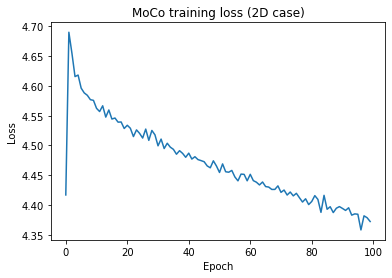

In [15]:
plt.figure()
plt.plot(losses_2d)
plt.title("MoCo training loss (2D case)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [16]:
# Эмбеддинги
moco_2d.encoder_q.eval()
with torch.no_grad():
    z2d = moco_2d.encoder_q(torch.from_numpy(X2d).to(device)).cpu().numpy()

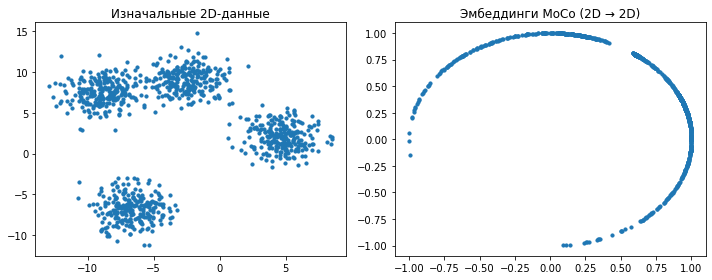

In [17]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X2d[:, 0], X2d[:, 1], s=10)
plt.title("Изначальные 2D-данные")
plt.subplot(1, 2, 2)
plt.scatter(z2d[:, 0], z2d[:, 1], s=10)
plt.title("Эмбеддинги MoCo (2D → 2D)")
plt.tight_layout()
plt.show()

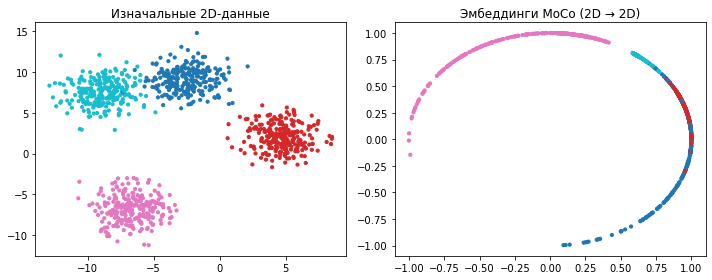

In [18]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X2d[:, 0], X2d[:, 1], c=y2d, cmap="tab10", s=10)
plt.title("Изначальные 2D-данные")
plt.subplot(1, 2, 2)
plt.scatter(z2d[:, 0], z2d[:, 1], c=y2d, cmap="tab10", s=10)
plt.title("Эмбеддинги MoCo (2D → 2D)")
plt.tight_layout()
plt.show()


## Демонстрация 2: High-dimensional данные → 2D эмбеддинги (снижение размерности)

Теперь создадим данные в более высокой размерности (например, 20 измерений) с несколькими кластерами.  
Здесь MoCo будет выполнять **нелинейное снижение размерности** до 2D, сохраняя структуру кластеров.


In [19]:
# Генерируем high-dimensional данные
X_hd, y_hd = generate_blobs_high_dim(
    n_samples=3000,
    n_clusters=4,
    n_features=20,
    cluster_std=1.2,
    random_state=123
)

In [20]:
print("High-dimensional data shape:", X_hd.shape)

# Обучаем MoCo (20D -> 2D)
input_dim_hd = X_hd.shape[1]
moco_hd, losses_hd = train_moco(
    X_hd, y_hd,
    input_dim=input_dim_hd,
    proj_dim=2,
    hidden_dim=128,
    K=1024,
    m=0.999,
    T=0.07,
    batch_size=256,
    epochs=100,
    lr=1e-3,
    device=device,
    noise_std=0.1,
)

High-dimensional data shape: (3000, 20)
Epoch [10/100]  Loss: 5.5182
Epoch [20/100]  Loss: 5.3883
Epoch [30/100]  Loss: 5.3542
Epoch [40/100]  Loss: 5.3298
Epoch [50/100]  Loss: 5.3051
Epoch [60/100]  Loss: 5.2840
Epoch [70/100]  Loss: 5.2636
Epoch [80/100]  Loss: 5.2419
Epoch [90/100]  Loss: 5.2170
Epoch [100/100]  Loss: 5.1980


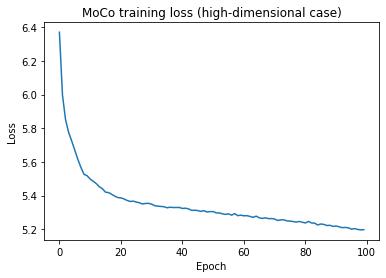

In [21]:
plt.figure()
plt.plot(losses_hd)
plt.title("MoCo training loss (high-dimensional case)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
# Эмбеддинги MoCo
moco_hd.encoder_q.eval()
with torch.no_grad():
    z_hd = moco_hd.encoder_q(torch.from_numpy(X_hd).to(device)).cpu().numpy()

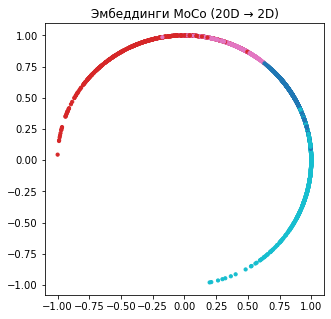

In [23]:
plt.figure(figsize=(5, 5))
plt.scatter(z_hd[:, 0], z_hd[:, 1], c=y_hd, cmap="tab10", s=10)
plt.title("Эмбеддинги MoCo (20D → 2D)")
plt.show()


## Сравнение с UMAP на тех же high-dimensional данных

Теперь применим **UMAP** к тем же high-dimensional данным и посмотрим,  
какую 2D-структуру он даёт по сравнению с MoCo.


In [24]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_hd)

/Users/mkrinitskiy/conda/envs/torch/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


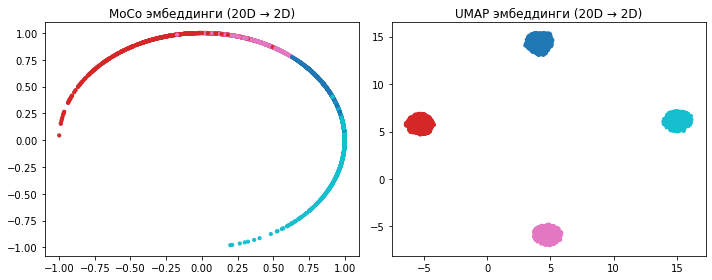

In [25]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(z_hd[:, 0], z_hd[:, 1], c=y_hd, cmap="tab10", s=10)
plt.title("MoCo эмбеддинги (20D → 2D)")
plt.subplot(1, 2, 2)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_hd, cmap="tab10", s=10)
plt.title("UMAP эмбеддинги (20D → 2D)")
plt.tight_layout()
plt.show()


## Резюме

В этом ноутбуке мы:

- Реализовали упрощённую версию **MoCo** с momentum-энкодером и InfoNCE loss.
- Показали, что на 2D-данных MoCo создаёт новое пространство признаков, в котором реализуется понятие близости объектов
- На high-dimensional данных (20D) использовали MoCo как метод снижения размерности до 2D, в котором также увидели, что реализовано понятие близости объектов
- Сравнили результат с **UMAP**, который является "классическим" методом нелинейного снижения размерности.

## ВОПРОСЫ
- Сохраняется ли структура кластеров при использовании MoCo?
- MoCo реализовал понятие близости объектов. Исходя из какой логики это понятие было унаследовано? Что нужно сделать, чтобы понятие близости было унаследовано "правильнее"?

In [26]:
class BlobDataset(Dataset):
    def __init__(self, X, y, noise_std=0.05):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()
        self.noise_std = noise_std

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        label = self.y[idx]

        # Две аугментации одной точки (позитивная пара)
        aug1 = x + self.noise_std * torch.randn_like(x)
        idx2 = np.random.choice(np.where(self.y == label)[0], 1)[0]
        x2 = self.X[idx2]
        aug2 = x2 + self.noise_std * torch.randn_like(x)
        return aug1, aug2, label


In [27]:
print("High-dimensional data shape:", X_hd.shape)

# Обучаем MoCo (20D -> 2D)
input_dim_hd = X_hd.shape[1]
moco_hd, losses_hd = train_moco(
    X_hd, y_hd,
    input_dim=input_dim_hd,
    proj_dim=2,
    hidden_dim=128,
    K=1024,
    m=0.999,
    T=0.07,
    batch_size=256,
    epochs=100,
    lr=1e-3,
    device=device,
    noise_std=0.1,
)

High-dimensional data shape: (3000, 20)
Epoch [10/100]  Loss: 5.4858
Epoch [20/100]  Loss: 5.3721
Epoch [30/100]  Loss: 5.3102
Epoch [40/100]  Loss: 5.2758
Epoch [50/100]  Loss: 5.2552
Epoch [60/100]  Loss: 5.2432
Epoch [70/100]  Loss: 5.2333
Epoch [80/100]  Loss: 5.2236
Epoch [90/100]  Loss: 5.2229
Epoch [100/100]  Loss: 5.2195


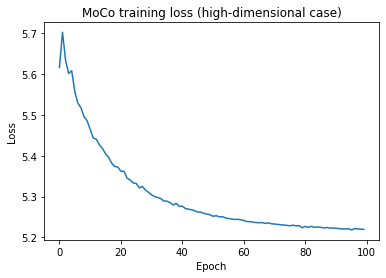

In [28]:
plt.figure()
plt.plot(losses_hd)
plt.title("MoCo training loss (high-dimensional case)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [29]:
# Эмбеддинги MoCo
moco_hd.encoder_q.eval()
with torch.no_grad():
    z_hd = moco_hd.encoder_q(torch.from_numpy(X_hd).to(device)).cpu().numpy()

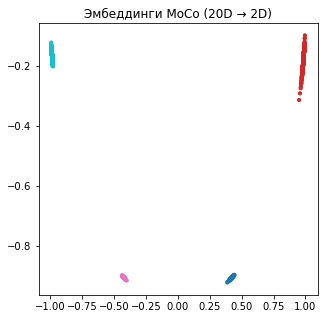

In [30]:
plt.figure(figsize=(5, 5))
plt.scatter(z_hd[:, 0], z_hd[:, 1], c=y_hd, cmap="tab10", s=10)
plt.title("Эмбеддинги MoCo (20D → 2D)")
plt.show()

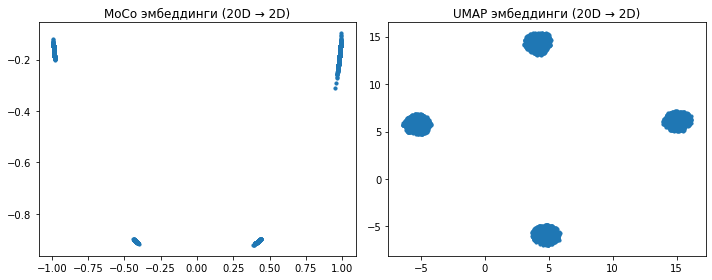

In [32]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# plt.scatter(z_hd[:, 0], z_hd[:, 1], c=y_hd, cmap="tab10", s=10)
plt.scatter(z_hd[:, 0], z_hd[:, 1], s=10)
plt.title("MoCo эмбеддинги (20D → 2D)")
plt.subplot(1, 2, 2)
# plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_hd, cmap="tab10", s=10)
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=10)
plt.title("UMAP эмбеддинги (20D → 2D)")
plt.tight_layout()
plt.show()